# 🧬 Análisis del Microbioma Humano

##  Objetivo

El objetivo de este análisis es explorar la composición del microbioma humano y comprender cómo se distribuyen los distintos microorganismos en diferentes partes del cuerpo.

A través de un análisis exploratorio de datos (EDA), se busca identificar patrones, microorganismos predominantes y posibles relaciones entre las distintas regiones del cuerpo humano.

## 📦 Carga de datos

En esta sección se realiza la carga del dataset y una primera inspección para comprender su estructura, dimensiones y tipos de datos.

Esto permite tener una visión general del contenido y detectar posibles problemas como valores faltantes o tipos de datos incorrectos.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_mb = pd.read_csv(r"C:\microbiome-data-analysis\data\project_catalog.csv")

data_mb.head()

,HMP ID,GOLD ID,Organism Name,Domain,NCBI Superkingdom,HMP Isolation Body Site,Project Status,Current Finishing Level,NCBI Submission Status,NCBI Project ID,Genbank ID,Gene Count,IMG/HMP ID,HOMD ID,Sequencing Center,Funding Source,Strain Repository ID
0,1,Gi03551,Abiotrophia defectiva ATCC 49176,BACTERIAL,Bacteria,oral,Complete,Level 3: Improved-High-Quality Draft,6. annotation (and sequence) public on NCBI site,33011,ACIN00000000,1950,643886181,HOMD: tax_389,Washington University Genome Sequencing Center,NIH-HMP Jumpstart Supplement,"ATCC 49176, CIP 103242"
1,4,Gi03555,Achromobacter piechaudii ATCC 43553,BACTERIAL,Bacteria,airways,Complete,Level 2: High-Quality Draft,6. annotation (and sequence) public on NCBI site,46343,ADMS00000000,5755,647000200,NaN,Baylor College of Medicine,NIH-HMP Jumpstart Supplement,"ATCC 43553, CIP 55774, LMG 6100"
2,5,Gi03554,Achromobacter xylosoxidans C54,BACTERIAL,Bacteria,airways,Complete,Level 5: Non-contiguous Finished,6. annotation (and sequence) public on NCBI site,38739,ACRC00000000,6010,0,HOMD: tax_343,Broad Institute,NIH-HMP Jumpstart Supplement,BEI HM-235
3,10,Gi03422,Acinetobacter baumannii ATCC 19606,BACTERIAL,Bacteria,urogenital_tract,Complete,Level 2: High-Quality Draft,6. annotation (and sequence) public on NCBI site,38509,ACQB00000000,3832,647533101,HOMD: tax_554,Broad Institute,NIH-HMP Jumpstart Supplement,"ATCC 19606, DSM 6974"
4,12,Gi03421,Acinetobacter calcoaceticus RUH2202,BACTERIAL,Bacteria,skin,Complete,Level 2: High-Quality Draft,6. annotation (and sequence) public on NCBI site,38337,ACPK00000000,3632,646206267,NaN,Broad Institute,NIH-HMP Jumpstart Supplement,LMG 10517


## Exploración inicial

Se analiza la estructura del dataset para entender la cantidad de registros, variables y tipos de datos disponibles.

In [7]:
data_mb.shape

(2915, 17)

In [8]:
data_mb.info()

<class 'pandas.DataFrame'>
RangeIndex: 2915 entries, 0 to 2914
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   HMP ID                   2915 non-null   int64
 1   GOLD ID                  1783 non-null   str  
 2   Organism Name            2915 non-null   str  
 3   Domain                   2712 non-null   str  
 4   NCBI Superkingdom        2751 non-null   str  
 5   HMP Isolation Body Site  2915 non-null   str  
 6   Project Status           2915 non-null   str  
 7   Current Finishing Level  1579 non-null   str  
 8   NCBI Submission Status   2915 non-null   str  
 9   NCBI Project ID          2915 non-null   int64
 10  Genbank ID               1579 non-null   str  
 11  Gene Count               2915 non-null   int64
 12  IMG/HMP ID               2915 non-null   int64
 13  HOMD ID                  397 non-null    str  
 14  Sequencing Center        2911 non-null   str  
 15  Funding Source 

In [21]:
data_mb.describe()

,HMP ID,NCBI Project ID,Gene Count,IMG/HMP ID
count,2915.000000,2915.000000,2915.000000,2.915000e+03
mean,3193.047684,152890.012007,1474.622642,2.250715e+08
std,3055.524395,104857.664414,1653.762393,5.295180e+08
min,1.000000,0.000000,0.000000,0.000000e+00
25%,1262.500000,49365.000000,0.000000,0.000000e+00
50%,2122.000000,169465.000000,1517.000000,0.000000e+00
75%,3096.500000,269820.500000,2489.500000,0.000000e+00
max,9999.000000,311149.000000,8490.000000,2.524023e+09


In [22]:
filas, columnas = data_mb.shape
print(f"El dataset contiene {filas} filas y {columnas} columnas.")

El dataset contiene 2915 filas y 17 columnas.


El volumen de datos es suficiente para identificar tendencias generales y relaciones entre las variables analizadas.

## 🧬 Análisis de variables

En esta sección se analizan las principales variables del dataset para identificar cuáles son más relevantes y cómo se distribuyen.

Se presta especial atención a la frecuencia de los microorganismos y su presencia en distintas partes del cuerpo.

In [23]:
data_mb.columns

Index(['HMP ID', 'GOLD ID', 'Organism Name', 'Domain', 'NCBI Superkingdom',
       'HMP Isolation Body Site', 'Project Status', 'Current Finishing Level',
       'NCBI Submission Status', 'NCBI Project ID', 'Genbank ID', 'Gene Count',
       'IMG/HMP ID', 'HOMD ID', 'Sequencing Center', 'Funding Source',
       'Strain Repository ID'],
      dtype='str')

El dataset contiene variables relacionadas con la identificación de microorganismos y su localización en distintas partes del cuerpo humano, lo que permite analizar la distribución del microbioma.

In [9]:
data_mb['Organism Name'].value_counts().head(10)

Organism Name
Aeromonas veronii AMC34                         3
Clostridium ramosum DSM 1402                    2
Selenomonas sputigena ATCC 35185                2
butyrate-producing bacterium SS3/4              2
Plesiomonas sp. HPP0020                         2
Capnocytophaga sp. oral taxon 412 str. F0487    2
Haemophilus parainfluenzae ATCC 33392           2
Facklamia languida CCUG 37842                   2
Abiotrophia defectiva ATCC 49176                1
Achromobacter piechaudii ATCC 43553             1
Name: count, dtype: int64

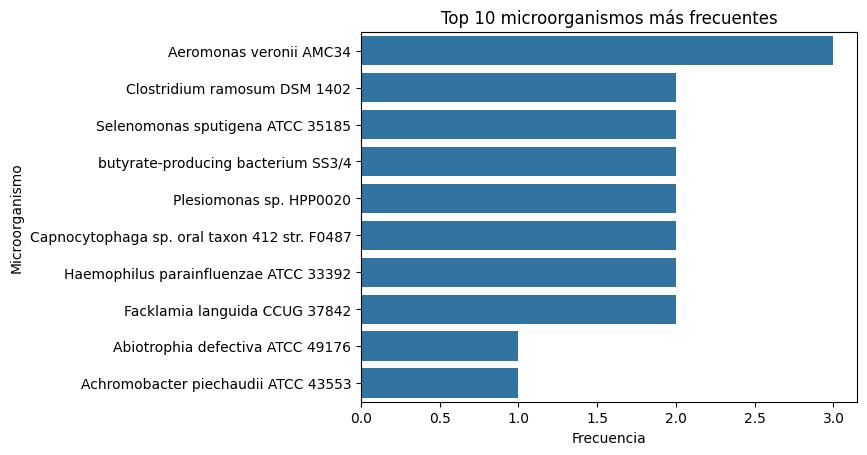

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

top_organismos = data_mb['Organism Name'].value_counts().head(10)

sns.barplot(x=top_organismos.values, y=top_organismos.index)
plt.title("Top 10 microorganismos más frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("Microorganismo")
plt.show()

Se identifican los microorganismos más frecuentes en el dataset. Algunos organismos aparecen con mayor recurrencia, lo que sugiere que tienen una presencia predominante dentro del microbioma humano analizado.

Además, se observa que la distribución no es uniforme, ya que un grupo reducido de microorganismos concentra la mayor cantidad de registros (Aeromonas veronii).

## 🧍 Distribución por parte del cuerpo

En esta sección se analiza cómo se distribuyen las muestras del microbioma en las distintas partes del cuerpo humano.

Esto permite identificar qué regiones están más representadas en el dataset y detectar posibles sesgos en los datos.

In [11]:
data_mb['HMP Isolation Body Site'].value_counts()

HMP Isolation Body Site
gastrointestinal_tract    745
unknown                   654
urogenital_tract          529
oral                      347
skin                      267
airways                   236
blood                      75
bone                       27
other                      13
eye                         8
wound                       4
ear                         4
nose                        2
heart                       2
liver                       1
lymph_nodes                 1
Name: count, dtype: int64

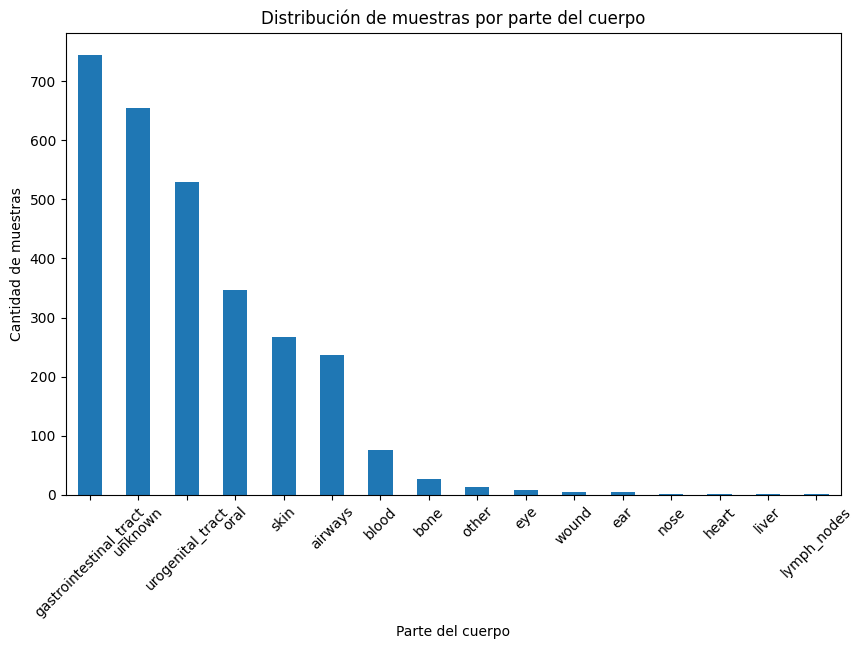

In [27]:
plt.figure(figsize=(10,6))

data_mb['HMP Isolation Body Site'].value_counts().plot(kind='bar')

plt.title("Distribución de muestras por parte del cuerpo")
plt.xlabel("Parte del cuerpo")
plt.ylabel("Cantidad de muestras")

plt.xticks(rotation=45)
plt.show()

Se observa que la mayor cantidad de muestras proviene del tracto gastrointestinal, seguido por categorías como "unknown" y el tracto urogenital.

Esto indica que el dataset está más concentrado en ciertas regiones del cuerpo, lo que podría influir en los resultados del análisis.

Además, algunas categorías presentan muy pocas observaciones, como corazón, hígado o ganglios linfáticos, lo que sugiere una menor representación de estas áreas.

La distribución desigual de las muestras sugiere un posible sesgo en la recolección de datos, lo cual es importante considerar al interpretar los resultados del análisis.

## 🔥 Relación entre microorganismos y partes del cuerpo

En esta sección se analiza la relación entre los distintos microorganismos y las partes del cuerpo donde se encuentran.

Se utiliza una tabla cruzada y un mapa de calor para visualizar patrones de distribución y posibles asociaciones entre variables.

In [34]:
# Tabla cruzada
body_bacteria = pd.crosstab(
    data_mb['HMP Isolation Body Site'],
    data_mb['Organism Name']  # ajustar si hace falta
)

# Top bacterias
top_bacteria = data_mb['Organism Name'].value_counts().head(15).index
top_bacteria

Index(['Aeromonas veronii AMC34', 'Clostridium ramosum DSM 1402',
       'Selenomonas sputigena ATCC 35185',
       'butyrate-producing bacterium SS3/4', 'Plesiomonas sp. HPP0020',
       'Capnocytophaga sp. oral taxon 412 str. F0487',
       'Haemophilus parainfluenzae ATCC 33392',
       'Facklamia languida CCUG 37842', 'Abiotrophia defectiva ATCC 49176',
       'Achromobacter piechaudii ATCC 43553', 'Achromobacter xylosoxidans C54',
       'Acinetobacter baumannii ATCC 19606',
       'Acinetobacter calcoaceticus RUH2202', 'Acinetobacter sp. SH024',
       'Acinetobacter sp. RUH2624'],
      dtype='str', name='Organism Name')

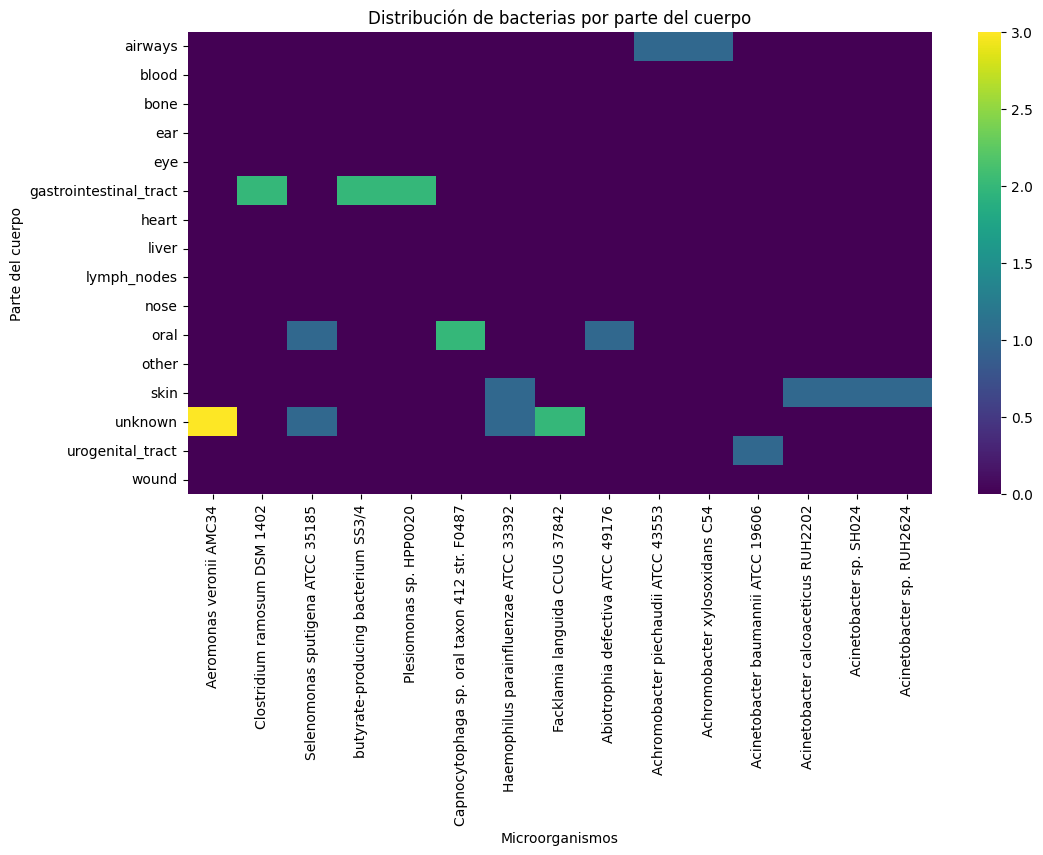

In [32]:
# Filtrar
filtered = body_bacteria[top_bacteria]

# Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(filtered, cmap="viridis")

plt.title("Distribución de bacterias por parte del cuerpo")
plt.xlabel("Microorganismos")
plt.ylabel("Parte del cuerpo")

plt.show()

El mapa de calor permite observar la relación entre los microorganismos más frecuentes y las distintas partes del cuerpo.

Se identifican patrones claros donde ciertos microorganismos predominan en regiones específicas, lo que sugiere una especialización del microbioma según la zona del cuerpo.

Asimismo, algunas bacterias aparecen distribuidas en múltiples regiones, lo que podría indicar una mayor adaptabilidad o presencia generalizada en el organismo.
    
Este tipo de análisis es clave para comprender la diversidad del microbioma humano y cómo varía según la localización, lo que puede tener implicancias en estudios de salud y enfermedades.

##  Diversidad del microbioma por parte del cuerpo

En esta sección se analiza la diversidad de microorganismos en cada parte del cuerpo utilizando el índice de Shannon.

Este índice permite medir no solo la cantidad de microorganismos, sino también la distribución de los mismos, proporcionando una visión más completa de la diversidad del microbioma.

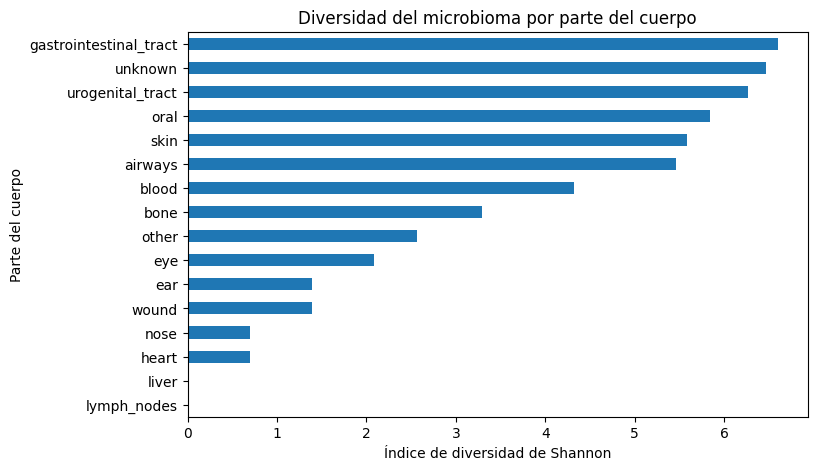

In [36]:
from scipy.stats import entropy
import matplotlib.pyplot as plt

# Tabla cruzada
table = pd.crosstab(
    data_mb['HMP Isolation Body Site'],
    data_mb['Organism Name']
)

# Índice de Shannon
shannon_index = table.apply(lambda x: entropy(x), axis=1)

# Ordenar valores
shannon_sorted = shannon_index.sort_values(ascending=False)

# Mostrar resultados
shannon_sorted

# Gráfico
shannon_sorted.sort_values().plot(kind='barh', figsize=(8,5))

plt.xlabel("Índice de diversidad de Shannon")
plt.ylabel("Parte del cuerpo")
plt.title("Diversidad del microbioma por parte del cuerpo")

plt.show()

El índice de Shannon permite evaluar la diversidad del microbioma en cada parte del cuerpo, considerando tanto la cantidad de microorganismos como su distribución.

Se observa que algunas regiones presentan mayor diversidad, lo que indica una mayor variedad de microorganismos distribuidos de manera más equilibrada.

En contraste, otras zonas muestran menor diversidad, lo que podría indicar la predominancia de ciertos microorganismos sobre otros.

Este análisis complementa el estudio de frecuencias, ya que permite entender no solo qué microorganismos están presentes, sino también cómo se distribuyen, aportando una visión más profunda del microbioma humano.

## Conclusiones

A partir del análisis exploratorio del dataset de microbioma humano, se pueden destacar las siguientes conclusiones:

- El microbioma presenta una distribución desigual, donde un grupo reducido de microorganismos concentra la mayor cantidad de registros.

- Existen diferencias claras entre las distintas partes del cuerpo, observándose que algunas regiones, como el tracto gastrointestinal, están más representadas en el dataset.

- El análisis de la relación entre microorganismos y partes del cuerpo evidencia patrones de especialización, donde ciertos microorganismos predominan en regiones específicas.

- El mapa de calor permitió visualizar estas asociaciones, mostrando cómo la presencia de microorganismos varía según la localización.

- A través del índice de Shannon, se identificaron diferencias en la diversidad del microbioma entre las distintas partes del cuerpo, indicando que algunas zonas presentan una mayor variedad y distribución más equilibrada de microorganismos.

En conjunto, estos hallazgos permiten comprender mejor la complejidad y variabilidad del microbioma humano, destacando la importancia de considerar la localización al analizar este tipo de datos.

## 🚀 Próximos pasos

Como líneas futuras de análisis, se podrían explorar modelos predictivos para identificar patrones más complejos o aplicar técnicas de clustering para agrupar perfiles de microbioma según características similares.